## Case Study  
# Bridging Strategy and Technical Delivery: A Data Science Journey in motion

## The problem: where do I fit?
During my consulting career at **Accenture's Data & AI Value Strategy** team, I realized that while I could navigate strategic problem solving and stakeholder engagement, I often found myself **on the edge of highly technical discussions** (i.e. model pipeline, data quality, ML algorithms, etc.), I could follow the logic, but I wished to be a more active and technically proficient participant.   

This gap frustrated me. It also gave me a clear view of something important: to my experience most candidates in the data science/IT consulting market sit at one extreme or the other, either deeply technical with limited business exposure or business savvy with superficial technical skills.

The question explored in this notebooks is: "*is there a measurable gap and is that where I'm heading?*"


The analysis reflects this transition. It is not intended as a finished product, the goal is not statistical inference, but as a live demonstration of how I think through problems.

In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


## Understanding the typical data science candidate pool
When evaluating candidates for data-related jobs, companies often faced with different profiles: computer science fresh graduates, business-oriented analysts, specialized engineers, researchers for instance.  
The challenge for each candidate is not to excel in absolute terms, but is to be aware of the environment, the competitiveness based on skills, background, attitude and how complementary a profile may be within a team.

This case study proposes a **simple analytical framework** to simulate representative candidate profiles and visualize positioning.   

These 9 dimensions were chosen to capture both sides of the technical/business divide.

In [ ]:
# Let's define candidate skill dimension: the selected dimensions are
# intentionally chosen to capture both technical and business-oriented aspects of data-related roles.
skill_dimension =[
    "technical_ML_skills", "programming", "business_acumen",
    "domain_knowledge","client_facing_ability","cross_industry",
    "flexibility","leadership","teamwork_ability"
]

*Disclaimer*: All profile are synthetically generated. The base means and standard deviations are my own reasoned estimates, they are not derived from empirical survey data. The goal is structural comparison, not precise benchmark. I am well aware I am comparing different seniorities, but it is useful for the purpose.

To model the competitive environment, I define six archetypal candidate profiles based on patterns commonly observed in data-related hiring:
- **Computer Science Graduate**: strong technical background, less experience in business context and client-facing roles
- **Business Analyst**: strong in business acumen and client facing ability but low technical ML and programming expertise
- **Expert Data Scientist**: Very high technical skills and domain knowledge, some leadership, teamwork and flexibility
- **Junior Data Analyst**: knowledge in business and domain, good at working cross-functional but not technically advanced
- **PhD/Research Background**: strong tech knowledge, domain expertise, leadership in research but may lack client-facing and cross-industry adaptibility
- **AI Engineer**: High level technical and ML skills, flexible, but low-medium business strength

In [ ]:
np.random.seed(42) # Reproducibility: same random draw every time

# Each profile is generated with a specific mean and std for each skill dimension, reflecting the typical strengths and weaknesses of candidates in that profile.
candidate_profiles = {
    # CS graduates
    "CS_Graduates" : np.array([np.random.normal([6.5,8,3,2,3,3,6,2,7],[0.8,0.8,0.7,0.6,0.5,0.6,0.7,0.5,0.5])
        for i in range(35)
    ]),

    # Business_Analyst
    "Business_Analyst" : np.array([np.random.normal([3,3.5,8,7,8,6,6,5,8],[0.8,0.7,0.6,0.7,0.6,0.7,0.7,0.7,0.6])
        for i in range(40)
    ]),

    # Expert Data Scientist
    "XP_Data_Scientist" : np.array([np.random.normal([9,8,6,8,4,5,7,6,7],[0.6,0.5,0.7,0.5,0.6,0.6,0.7,0.7,0.6])
        for i in range(35)
    ]),

    # Junior Data Science Analyst
    "Junior_Analyst" : np.array([np.random.normal([6,7,4.5,5,4,5,7,4,8],[0.9,0.8,0.7,0.8,0.7,0.8,0.7,0.8,0.7])
        for i in range(30)
    ]),

    # PhD/Research
    "Phd_Researcher" : np.array([np.random.normal([7,7,4,9,4,2.5,5.5,7,6],[0.7,0.6,0.8,0.5,0.6,0.7,0.7,0.7,0.7])
        for i in range(20)
    ]),

    # AI_Engineer
    "AI_Engineer" : np.array([np.random.normal([8,9,4.5,8,4.5,6,8,7,9],[0.6,0.5,0.7,0.7,0.8,0.7,0.8,0.7,0.6])
        for i in range(25)
    ]),
}

# Compile all standard candidates
all_candidates = []
candidate_labels = []

# Let's extend the list for all_candidates and candidate_labels
for profile_type, profiles in candidate_profiles.items():
    all_candidates.extend(profiles)
    candidate_labels.extend([profile_type]*len(profiles))

# Create a dataframe
candidate_df = pd.DataFrame(all_candidates, columns = skill_dimension)
candidate_df.columns

# Need to add the profile type to the dataframe
candidate_df["Profile_Type"]=candidate_labels

In [ ]:
# Quick view on the new dataframe
candidate_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   technical_ML_skills    185 non-null    float64
 1   programming            185 non-null    float64
 2   business_acumen        185 non-null    float64
 3   domain_knowledge       185 non-null    float64
 4   client_facing_ability  185 non-null    float64
 5   cross_industry         185 non-null    float64
 6   flexibility            185 non-null    float64
 7   leadership             185 non-null    float64
 8   teamwork_ability       185 non-null    float64
 9   Profile_Type           185 non-null    object 
dtypes: float64(9), object(1)
memory usage: 14.6+ KB


In [ ]:
candidate_df.describe()

,technical_ML_skills,programming,business_acumen,domain_knowledge,client_facing_ability,cross_industry,flexibility,leadership,teamwork_ability
count,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000
mean,6.514799,6.804454,5.232134,6.298750,4.788318,4.737593,6.642827,4.959320,7.582195
std,2.190968,1.949239,1.947553,2.446570,1.838259,1.453306,1.011381,1.901851,1.023604
min,1.629492,2.052791,1.166178,1.207726,2.043360,0.686270,4.633539,1.006216,4.714656
25%,5.476487,5.941528,3.814215,4.882398,3.501766,3.585327,5.875657,3.921328,6.776461
50%,6.911029,7.277191,4.929463,7.162435,4.157329,5.033929,6.529819,5.100565,7.589615
75%,8.266723,8.115780,6.756547,8.016822,5.553692,5.906188,7.295345,6.532290,8.255473
max,10.297953,10.003046,9.467451,9.855854,9.005862,7.507228,10.046559,8.623531,10.001943


In [ ]:
# Random generation can produce values outside the expected range (0-10)
# I want my values only to have one decimal and maximum value should be 10
# in this case I could modify only the columns I am interested in but since an user might add randomness in the syntehtic data simulation process, I'll set the max_value for each column
max_value = 10
min_value=0
candidate_df[skill_dimension] = candidate_df[skill_dimension].clip(upper=max_value, lower=min_value)

# As we are measuring proficiency I would reduce the decimal values at 1 decimal
candidate_df[skill_dimension] = candidate_df[skill_dimension].round(1)


In [ ]:
candidate_df.describe()

,technical_ML_skills,programming,business_acumen,domain_knowledge,client_facing_ability,cross_industry,flexibility,leadership,teamwork_ability
count,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000,185.000000
mean,6.513514,6.804865,5.229730,6.296216,4.785946,4.735135,6.638919,4.958378,7.585405
std,2.187087,1.945907,1.945098,2.449365,1.839015,1.451427,1.011133,1.900957,1.020578
min,1.600000,2.100000,1.200000,1.200000,2.000000,0.700000,4.600000,1.000000,4.700000
25%,5.500000,5.900000,3.800000,4.900000,3.500000,3.600000,5.900000,3.900000,6.800000
50%,6.900000,7.300000,4.900000,7.200000,4.200000,5.000000,6.500000,5.100000,7.600000
75%,8.300000,8.100000,6.800000,8.000000,5.600000,5.900000,7.300000,6.500000,8.300000
max,10.000000,10.000000,9.500000,9.900000,9.000000,7.500000,10.000000,8.600000,10.000000


In [ ]:
candidate_df["Profile_Type"].value_counts()

,count
Profile_Type,
Business_Analyst,40
CS_Graduates,35
XP_Data_Scientist,35
Junior_Analyst,30
AI_Engineer,25
Phd_Researcher,20


## Visualizing the landscape  
Before placing myself in this space, the chart below shows the average proficiency per skill dimension for each candidate type.

In [ ]:
# Let's do some plots

overview_profile=candidate_df.groupby("Profile_Type")[skill_dimension].mean()
print(overview_profile)


                   technical_ML_skills  programming  business_acumen  \
Profile_Type                                                           
AI_Engineer                   8.124000     8.968000         4.536000   
Business_Analyst              2.965000     3.602500         8.092500   
CS_Graduates                  6.691429     7.825714         2.917143   
Junior_Analyst                6.320000     6.686667         4.640000   
Phd_Researcher                7.260000     6.860000         3.895000   
XP_Data_Scientist             8.980000     7.968571         6.034286   

                   domain_knowledge  client_facing_ability  cross_industry  \
Profile_Type                                                                 
AI_Engineer                7.972000               4.984000        5.936000   
Business_Analyst           7.047500               7.842500        5.852500   
CS_Graduates               2.045714               2.942857        3.200000   
Junior_Analyst             4.9933

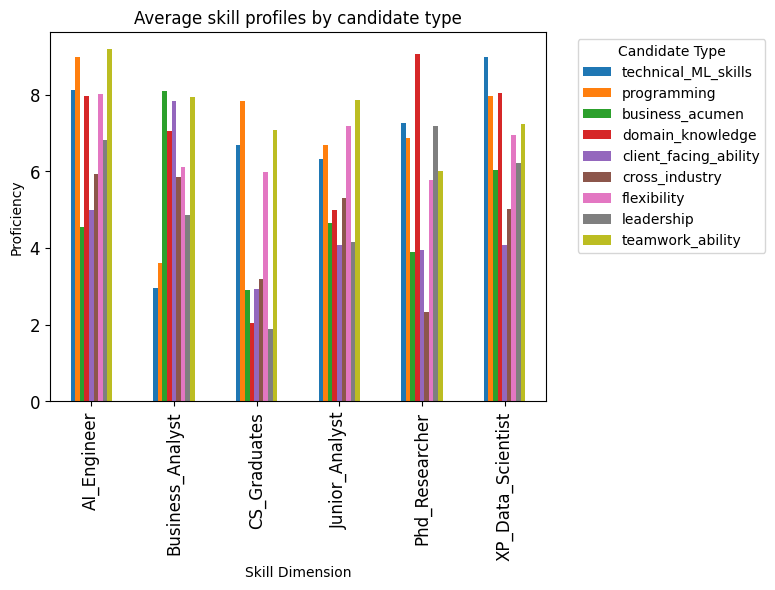

In [ ]:
# Bar Plots to highlight average profiles by type
overview_profile.plot(kind="bar", title = "Average skill profiles by candidate type", fontsize=12, xlabel="Skill Dimension", ylabel="Proficiency")
plt.legend(title='Candidate Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Most profiles show a **clear strength specialization**.
Key things to notice:  
- Business Analysts and Computer Science graduates show opposite skill set proficiency
- AI Engineers and Expert Data Scientists score highest on technical dimensions
- Researchers are most technically deep but not much cross-industry adaptable  


Rather than plotting all dimensions at once, I reduce to two summary axes useful to build intuition:  
- technical_profile = average of ML skills + programming
- business_profile = average of business acumen, domain knowledge, cross-industry expertise.

In [ ]:
# let's plot the technical vs the business overview
candidate_df["technical_profile"] = (candidate_df["technical_ML_skills"]+ candidate_df["programming"])/2
candidate_df["business_profile"] = (candidate_df["business_acumen"]+candidate_df["cross_industry"]+candidate_df["domain_knowledge"])/3

In [ ]:
candidate_df["technical_profile"] = candidate_df["technical_profile"].round(1)
candidate_df["business_profile"] = candidate_df["business_profile"].round(1)

In [ ]:
candidate_df

,technical_ML_skills,programming,business_acumen,domain_knowledge,client_facing_ability,cross_industry,flexibility,leadership,teamwork_ability,Profile_Type,technical_profile,business_profile
0,6.9,7.9,3.5,2.9,2.9,2.9,7.1,2.4,6.8,CS_Graduates,7.4,3.1
1,6.9,7.6,2.7,2.1,2.0,2.0,5.6,1.5,7.2,CS_Graduates,7.2,2.3
2,5.8,6.9,4.0,1.9,3.0,2.1,5.6,2.1,6.4,CS_Graduates,6.4,2.7
3,6.8,7.5,2.8,1.6,3.9,3.0,5.3,2.4,6.4,CS_Graduates,7.2,2.5
4,6.7,6.4,2.1,2.1,3.4,3.1,5.9,1.8,6.3,CS_Graduates,6.6,2.4
...,...,...,...,...,...,...,...,...,...,...,...,...
180,8.1,8.3,5.1,7.5,6.0,6.8,7.6,7.9,9.0,AI_Engineer,8.2,6.5
181,8.5,9.2,3.9,7.5,5.3,5.8,7.7,6.3,9.3,AI_Engineer,8.8,5.7
182,9.2,8.5,4.5,9.0,4.4,6.3,7.2,7.3,8.9,AI_Engineer,8.8,6.6
183,8.6,9.6,6.3,8.4,4.8,6.1,7.7,7.2,8.8,AI_Engineer,9.1,6.9


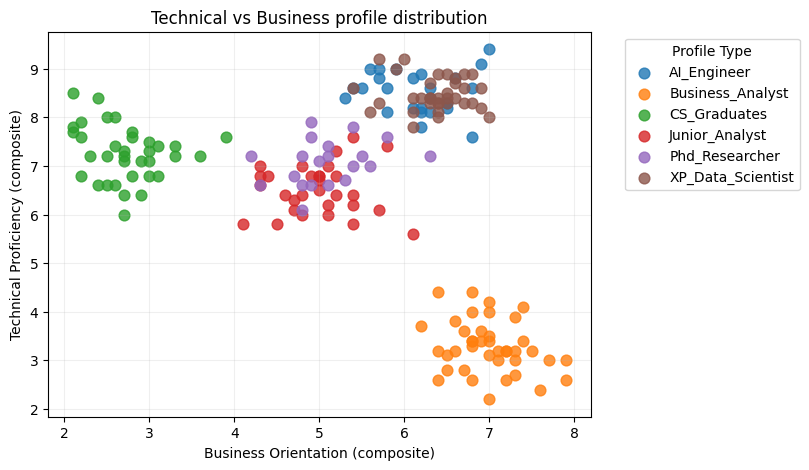

In [ ]:
fig, ax = plt.subplots (figsize =(7,5))

for label, df_sub in candidate_df.groupby("Profile_Type"):
    ax.scatter(
        df_sub["business_profile"],
        df_sub["technical_profile"],
        label=label,
        s=60,
        alpha=0.8
    )

ax.set_title("Technical vs Business profile distribution")
ax.set_xlabel("Business Orientation (composite)")
ax.set_ylabel("Technical Proficiency (composite)")
ax.legend(title = "Profile Type",bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha =0.2)
plt.show()

Most profiles cluster along the diagonal either technically strong or business strong.
Of course, this 2D projection is limited as we are not considering the soft-skill set which is vital in a company environment. The radar chart and PCA that follow give a more complete view.

## My current position  

In the following section I am mapping my own profile.  

**My Academic Background**  
During my studies in *Economics at the Universität Hamburg*, I conducted several independent research activities, using econometric techniques to address real-world challenges, i.e., I investigated the role of non-pharmaceutical health policies as containment measures during the Covid19 pandemic using the Difference-in-Differences estimation technique or analyzed Uber usage during the Covid19 pandemic in the U.S. from March ’20 to August ’21, to determine whether it acted as a complement to or substitute for public transportation, given its “social distancing” characteristic. The program gave me the confidence to navigate complex relationships between economic reasoning and policy actions.
After graduating in 2022, the emergence of widely accessible generative AI systems impressed me seeing how a complex technology was transformed into something easily accessible. Since then, I’ve focused on helping businesses embrace this shift, with a growing interest in the role that scalable data systems and advanced analytics play in enabling meaningful AI-powered solutions. For these reasons, I am currently pursuing a *Specialized Master’s in Data Science and Big Data at ULB*.

**My Previous Work Experience**  
Starting my career in the technology and consulting sector allowed me to explore both business strategy and data-driven innovation. As *Data & AI Value Strategy Consultant at Accenture*, I work alongside AI and tech experts harnessing the power of data. I contributed to the design and implementation of a *large-scale data analytics process* to monitor defective airbag replacements as part of a €1B safety recall initiative, processing of millions of vehicle-level records across multiple European markets. In another project, I provided functional support for *ETL processes* involving large datasets, using Excel and SAP tools to optimize the risk management system in compliance with regulatory metrics. I’ve been assisting businesses in identifying *strategic use cases for generative AI* by conducting feasibility analyses under the evolving EU regulations, reinforcing my view that AI effectiveness depends on robust, scalable data systems.. Across projects, I’ve developed practical skills in *SQL, Python, advanced Excel (PowerQuery) and Snowflake*. To streamline tasks,. I also designed an agentic AI framework using a proprietary low-code platform to orchestrate specialized agents for document drafting, demonstrating how automation can accelerate complex consulting workflows.

In [ ]:
# Scores are self-assessed.

Lisa_Profile = pd.DataFrame({
    "technical_ML_skills": [6.0], # Studying ML: supervised, unsupervised, statistical foundation
    "programming" : [6.5], # Python, SQL, R, Snowflake, Excel - used in real projects
    "business_acumen" : [8.0],  #2.5 years of work experience in Accenture (Data & AI Value Strategy Team - Milan (IT))
    "domain_knowledge":[7.5], # Ability to be proactive in learning and studying
    "client_facing_ability":[8.0], # Workshops, stakeholder reporting, C-suite communication
    "cross_industry":[7.5], # Multi-sector exposure across automotive, finance, regulation
    "flexibility":[8.5], # Fundamental consulting skill, able to switch context at speed
    "leadership":[6.5], # Few months before enrolling to university, promoted and led a small team
    "teamwork_ability":[8.0] # Cross-functional in both agile and waterfall contexts
    })

I normalize each dimension relative to the market baseline (the mean and standard deviations across all 185 synthetic profiles)

In [ ]:
# Market Normalization
# Normalized each median profile relative to the overall market. Used median to make the analysis more robust.
market_stats = candidate_df[skill_dimension]
market_mean = market_stats.mean()
market_std  = market_stats.std()

overview_profile=(
    candidate_df
    .groupby("Profile_Type")[skill_dimension]
    .median()
)

#How many standard deviations from the market average?
overview_norm=(
    overview_profile-market_mean)/market_std

In [ ]:
Lisa_norm = (Lisa_Profile[skill_dimension]-market_mean)/market_std

In [ ]:
overview_norm.loc["Lisa"] = Lisa_norm.values[0]

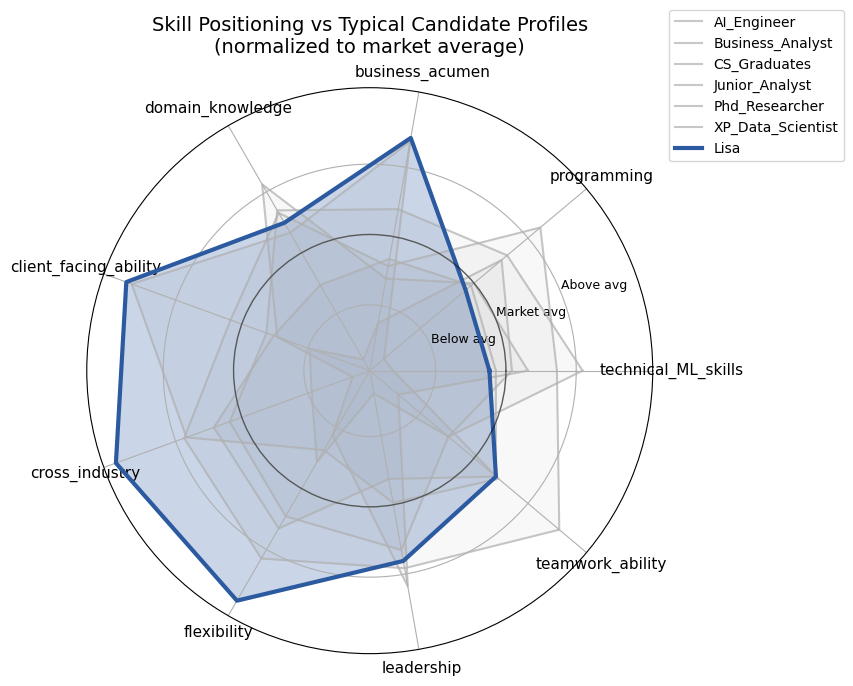

In [ ]:
def closed_loop(values):
    """Close the radar chart polygon by appending the first value at the end."""
    return np.concatenate([values, values[:1]])

angles = np.linspace(0, 2 * np.pi, len(skill_dimension), endpoint=False)
angles = np.concatenate([angles, [angles[0]]])

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

base_color      = "#B0B0B0"   # muted gray for all other profiles
highlight_color = "#2C5AA0"   # professional blue for Lisa

for profile in overview_norm.index:
    values = closed_loop(overview_norm.loc[profile].values)
    if profile == "Lisa":
        ax.plot(angles, values, linewidth=3, color=highlight_color, label="Lisa")
        ax.fill(angles, values, color=highlight_color, alpha=0.25)
    else:
        ax.plot(angles, values, linewidth=1.5, color=base_color, alpha=0.7, label=profile)
        ax.fill(angles, values, color=base_color, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(skill_dimension, fontsize=11)
ax.axhline(0, color="black", linewidth=1, alpha=0.5)  # market average reference line
ax.set_yticks([-1, 0, 1])
ax.set_yticklabels(["Below avg", "Market avg", "Above avg"], fontsize=9)
ax.set_title(
    "Skill Positioning vs Typical Candidate Profiles\n(normalized to market average)",
    pad=25, fontsize=14
)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=10)
plt.tight_layout()
plt.show()


# Please note the visualization has been coded with vibe coding, which is a design approach that emphasizes aesthetics and emotional impact to create engaging and visually appealing graphics.

My profile sits above the market average on the business dimensions and soft-skill set, but slightly below average on the technical axis, to be more precise technical_ML_skills and programming.   
**This weakness is actually the gap that the master's program and a project specific hands-on experience in the company is designed to close**.

## Applying Principal Component Analysis to project all 9 dimensions simultaneously into two components to maintain as much variance as possible.  
What is interesting about PCA is that it doesn't pre-assign which features belong to the "technical" or "business" axis, but it lets the data decide.

In [ ]:
print(candidate_df.columns)

Index(['technical_ML_skills', 'programming', 'business_acumen',
       'domain_knowledge', 'client_facing_ability', 'cross_industry',
       'flexibility', 'leadership', 'teamwork_ability', 'Profile_Type',
       'technical_profile', 'business_profile'],
      dtype='object')


In [ ]:
Lisa_Profile["Profile_Type"] = "Lisa"

In [ ]:
print(Lisa_Profile)

   technical_ML_skills  programming  business_acumen  domain_knowledge  \
0                  6.0          6.5              8.0               7.5   

   client_facing_ability  cross_industry  flexibility  leadership  \
0                    8.0             7.5          8.5         6.5   

   teamwork_ability Profile_Type  
0               8.0         Lisa  


In [ ]:
# Append Lisa profile to dataframe
candidate_df = pd.concat([candidate_df, Lisa_Profile], ignore_index=True)

# Normalize the entire dataframe for PCA
candidate_df_norm = candidate_df.copy()
scaler=StandardScaler()
scaled_data=scaler.fit_transform(candidate_df_norm[skill_dimension])

In [ ]:
# Performing a PCA for dimensionality reduction
pca = PCA(n_components=2) # Reduce to 2 dimensions for easy visualization
pca_components = pca.fit_transform(scaled_data)

# Create a dataframe with the PCA components
pca_df=pd.DataFrame(data=pca_components, columns=["PC1","PC2"])
pca_df["Profile_Type"] = candidate_df_norm["Profile_Type"].values

# Explained variance ratio
explained_variance = pca.explained_variance_ratio_
print(f"Explained variance Ratio: {explained_variance}")


Explained variance Ratio: [0.40419278 0.27377423]


- PC1 explains 40% of the total variance
- PC2 explains 27% of the total variance
Together explain 67% of the variance in my data.  

This is a good results, as it means that just two components capture nearly 70% of the variability in the original data.  

It confirms that the underlying structure of the data is genuinely 2-dimensional, potentially matching the intuition that the market is organized primarily along the business/technical axis. But before making conclusion is important to interpret the components: loadings analysis.

In [ ]:
# Set the correct index to the Profile_Type column
pca_df['Profile_Type'] = candidate_df_norm["Profile_Type"].values
pca_df.set_index('Profile_Type', inplace=True)
print(pca_df.index)


Index(['CS_Graduates', 'CS_Graduates', 'CS_Graduates', 'CS_Graduates',
       'CS_Graduates', 'CS_Graduates', 'CS_Graduates', 'CS_Graduates',
       'CS_Graduates', 'CS_Graduates',
       ...
       'AI_Engineer', 'AI_Engineer', 'AI_Engineer', 'AI_Engineer',
       'AI_Engineer', 'AI_Engineer', 'AI_Engineer', 'AI_Engineer',
       'AI_Engineer', 'Lisa'],
      dtype='object', name='Profile_Type', length=186)


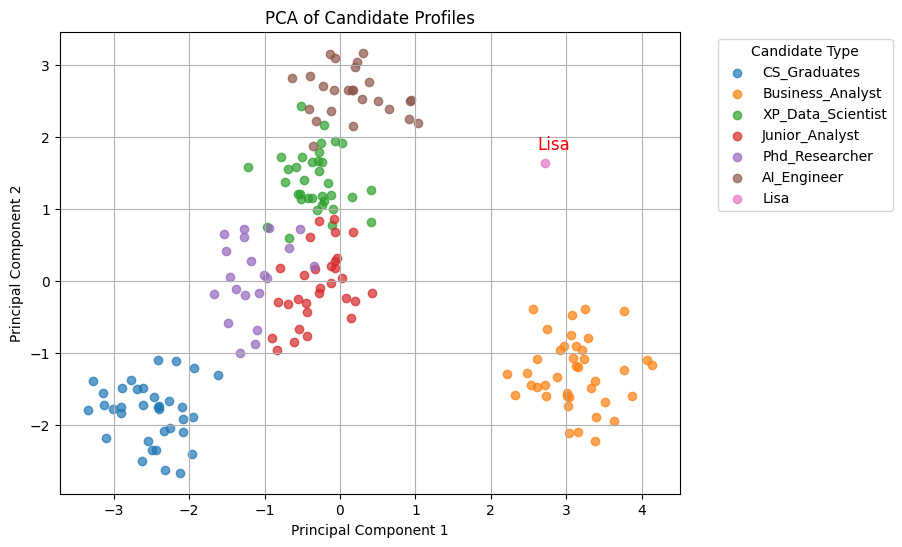

In [ ]:
# Plotting all profiles
plt.figure(figsize=(8,6))
for profile in pca_df.index.unique():
    subset=pca_df[pca_df.index==profile]
    plt.scatter(subset["PC1"], subset["PC2"], label=profile, alpha=0.7)


# Add a custom label for Lisa
plt.text(pca_df.loc["Lisa","PC1"]-0.1, pca_df.loc["Lisa","PC2"]+0.2, "Lisa", fontsize=12, color="red")

plt.title("PCA of Candidate Profiles")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Candidate Type", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True)
plt.show()

In [ ]:
loadings=pca.components_
loadings_df=pd.DataFrame(loadings.T, columns=["PC1","PC2"], index=skill_dimension)
print(loadings_df.sort_values("PC1", ascending=False).to_string())

                            PC1       PC2
client_facing_ability  0.486287 -0.068678
business_acumen        0.468835 -0.000103
cross_industry         0.368279  0.206679
domain_knowledge       0.250611  0.400332
teamwork_ability       0.211990  0.247300
leadership             0.168205  0.471270
flexibility            0.013646  0.460245
technical_ML_skills   -0.344695  0.418279
programming           -0.391216  0.349666


Looking at the PCA loadings, which provide a clear idea on how much each original feature contributes to the principal components (PC1 and PC2).  

For the **PC1**, the most represented features are business acumen, domain knowledge, cross industry, client-facing ability, while loads negatively on technical_ML_skills and programming skills. PC1, indeed, focuses more on the **business-related feature vs the technical profeciency**: moving to  the right, the profiles are more business oriented, on the contrary, moving left is more technical.   

**PC2** instead appears to capture the **depth of knowledge and seniority** axis as most of the weights is well reflected on leadership, domain knowledge and flexibility as well as technical ML skills. It means that moving up on the PCA plot, we can find more experienced and specialized profile.


## The trajectory: where am I going?  

The two important questions for myself (and a potential hiring manager) looking at this notebook are:
1) *Where I am now?*
2) *Where will I be in 12 months, after completing the Master and the intership/thesis?*

A key part of this educational path is not just acquiring new skills, from a technical point of view, completing the full-master's curriculum, especially related to Machine Learning foundations, data managements and big data management, but also ensuring they integrate with my existing business foundation.  
To visualize this I've added a "Projected 2026" profile to the PCA space.  

This point represents my target state following the completion of my *Specialized Master's at ULB* and a **technical project internship**.  

By boosting my scores in technical_ML_skills (9.0) and programming (8.5) while maintaining my business skills, the trajectory arrow moves upward towards a more depth and senior profile and slightly left towards a more technical skill set to apply to business/startup contexts.

In [ ]:
# Build a DataFrame with the same feature names used during scaler fitting
projected_values = [
    9.0, # technical_ML_skills: completing the ULB Specialized Master's in Data Science & Big Data
    8.5, # programming: improving coding skills through projects and courses
    8, # business_acumen: maintaining through work experience and proactive learning
    7.5, # domain_knowledge: deepened through thesis + internship
    8, # client_facing_ability: maintained
    7.5, # cross_industry: maintained through multi-sector experience
    8.5, # flexibility: maintained
    6.5, # leadership: slight growth
    8.0  # teamwork_ability: maintained and improved through projects
]
projected_df = pd.DataFrame([projected_values], columns=skill_dimension).astype(float)
projected_scaled = scaler.transform(projected_df)
projected_pca = pca.transform(projected_scaled)


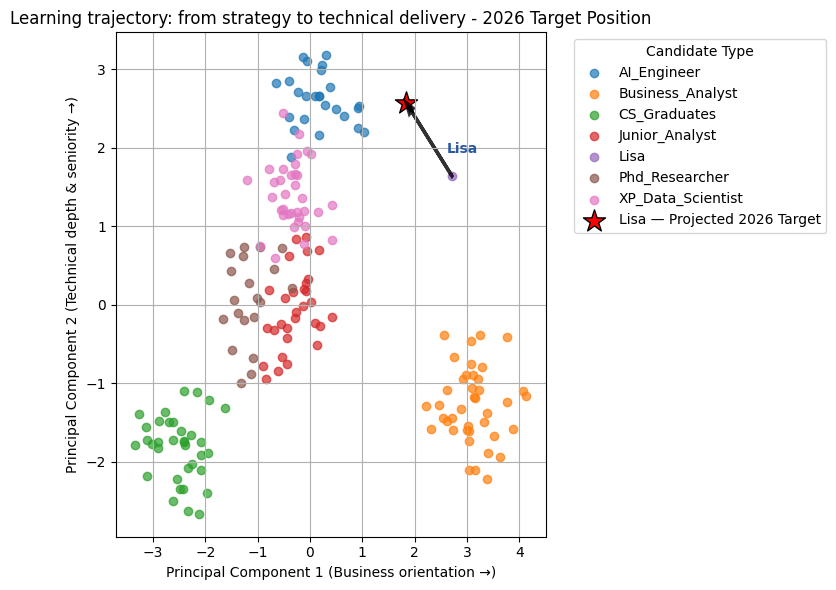

In [ ]:
# Plotting all profiles grouped by profile type (index is Profile_Type)
plt.figure(figsize=(8,6))
for profile, subset in pca_df.groupby(level=0):
    plt.scatter(subset["PC1"], subset["PC2"], label=profile, alpha=0.7)

# Plot projected 2026 position (computed in the previous cell)
try:
    plt.scatter(projected_pca[0,0], projected_pca[0,1], color="red", marker="*", s=280, edgecolors="black", linewidths=1, label="Lisa — Projected 2026 Target")
except NameError:
    pass

# Add a custom label for Lisa at her current PCA coordinates (robust if multiple rows)
if "Lisa" in pca_df.index:
    lisa_coords = pca_df.loc["Lisa", ["PC1", "PC2"]]
    if isinstance(lisa_coords, pd.DataFrame):
        lisa_point = lisa_coords.mean().values
    else:
        lisa_point = lisa_coords.values
    plt.text(lisa_point[0] - 0.1, lisa_point[1] + 0.3, "Lisa", fontsize=10, color="#2C5AA0", fontweight="bold")

# Add the trajectory line from current to projected position
if "Lisa" in pca_df.index:
    plt.arrow(lisa_point[0], lisa_point[1], projected_pca[0,0] - lisa_point[0], projected_pca[0,1] - lisa_point[1],
              color="black", linestyle="-", linewidth=2.5, head_width=0.1, length_includes_head=True, alpha=0.8)
plt.title("Learning trajectory: from strategy to technical delivery - 2026 Target Position")
plt.xlabel("Principal Component 1 (Business orientation →)")
plt.ylabel("Principal Component 2 (Technical depth & seniority →)")
plt.legend(title="Candidate Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

My current position sits at the far right of the business-oriented axis, above the Business Analyst profile, whereas my projected 2026 position moves directly into the upper right quadrant of the PCA space led by high business orientation and high technical depth, without sacrificing the business foundations I acquired through my studies and work experience.